<h1 style="color:darkblue; font-size:36px;">Chewing on Change</h1>
<h2 style="color:gray; font-size:24px;">Lesson 4: Using machine learning models to assess variation in fossilized horse teeth for species classification</h2>

# Coding
Coding is the process of writing instructions for computers to follow. These instructions are written in a programming language, which is a set of rules and syntax that computers can understand. Coding allows us to create software, websites, apps, and more. For this activity, you do not need to know how to write code, but it is our hope that you can follow along and see what the code is expected to do.
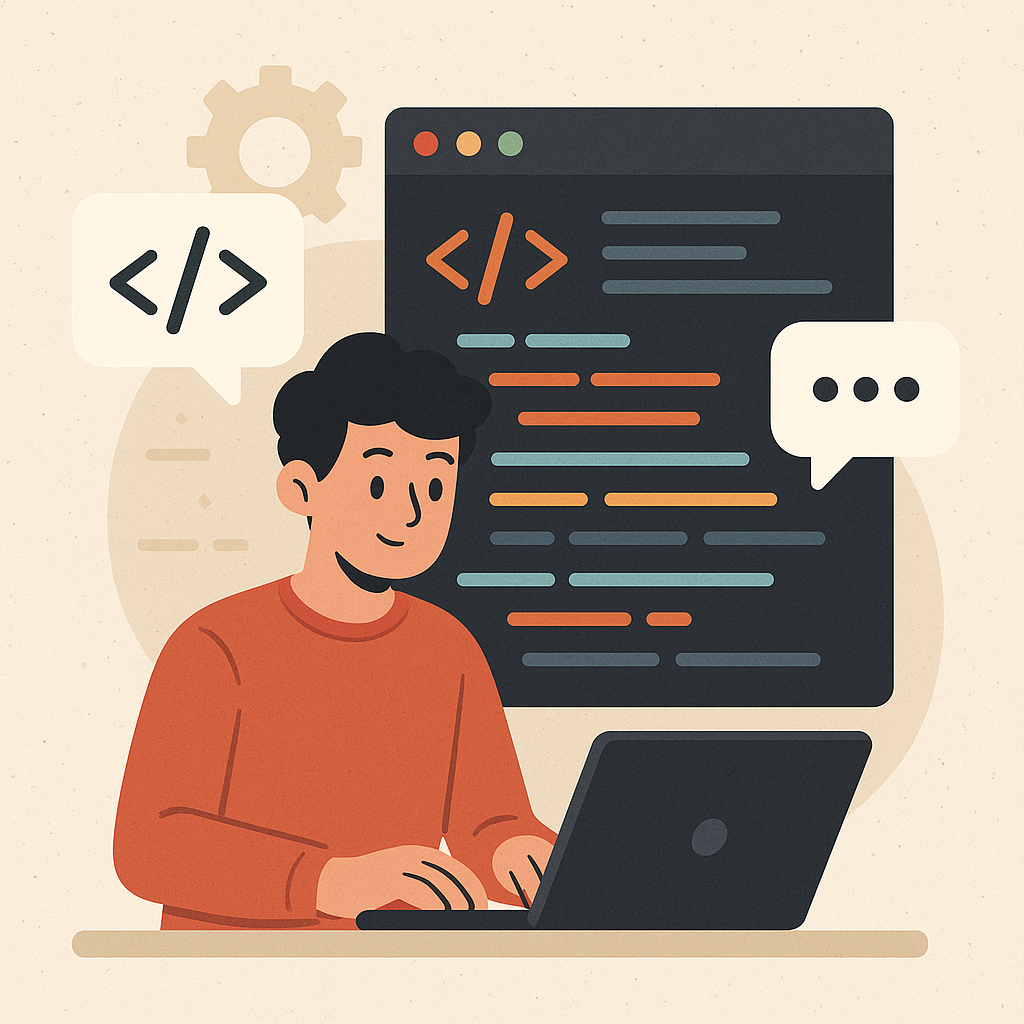

# Python
Python is a popular programming language known for its simplicity and readability. It's widely used in various fields, including web development, data analysis, artificial intelligence, and scientific computing. Python's syntax is designed to be easy to read and write, making it a great choice for beginners.

# Jupyter Notebook
A Jupyter Notebook is an open-source web application that allows you to create and share documents that contain live code, equations, visualizations, and narrative text. It's widely used in data science and machine learning for its interactive and user-friendly interface. You can write and execute Python code in a Jupyter Notebook, making it a powerful tool for experimentation and analysis. __This lesson is using a Jupyter Notebook!__

# Machine Learning
This assignment will use machine learning, a branch of artificial intelligence, that focuses on building systems that can learn from and make decisions based on data. Instead of being explicitly programmed to perform a task, machine learning algorithms use statistical techniques to improve their performance over time as they are exposed to more data. Machine learning can be categorized into two main types: supervised (uses labeled data to learn from) and unsupervised learning (models the features of a dataset without any reference labels). All this to say, machine learning is a powerful tool for data exploration and analysis!
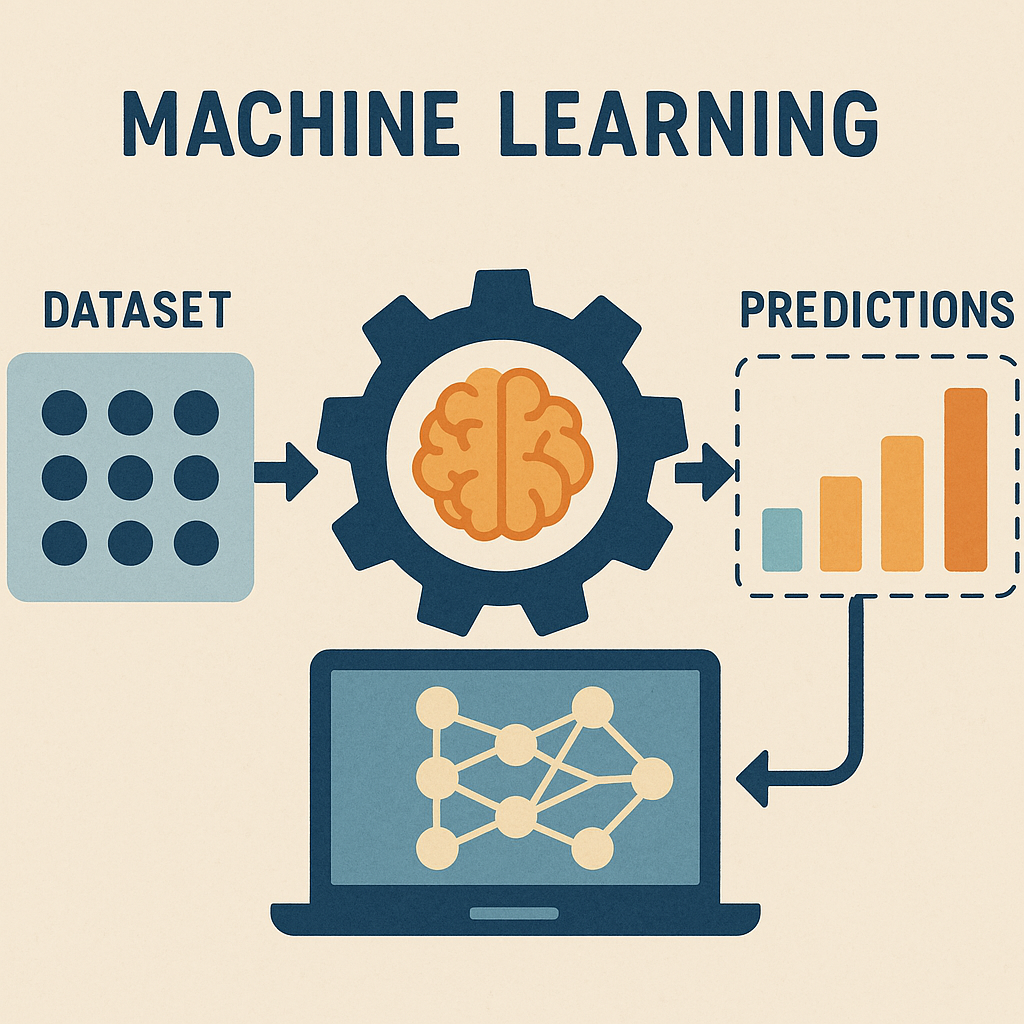

# CNNs (Convolutional Neural Networks)
A Convolutional Neural Network (CNN) is a type of deep learning algorithm that is particularly effective for analyzing visual data (images). CNNs are designed to automatically and adaptively learn features from images. They are widely used in image and video recognition, medical image analysis, and other areas where visual data is important.

__You will be testing how well CNNs do compared to humans in accurately identifying fossil horse species by visualizing images of their molar teeth. 
Does the CNN algorthim and computer vision model do as good or better than humans at identifying isolated teeth?__


# Let's Get Started!
For this exercise, we will explore image classification of upper molar teeth from six horse species representing over 55 million years of the fossil record: *Hyracotherium, Mesohippus sp., Parahippus leonensis, Nannippus aztecus, Dinohippus interpolatus, and Equus simplicidens*. 

*We will be starting with a "simple" neural network with "convolusional" layers and data augmentation, a technique to increase the size and diversity of the training dataset, to build a better model. You will be able to compare your model results to how well your group was able to properly classify the horse tooth images provided at the start of the lesson. If time allows, try adjusting some of these parameters and rerunning the code. Does it change your results dramatically? If so, how?*

In [18]:
# !pip install torchvision  # Uncomment if torchvision is not installed

In [17]:
# !pip install opencv-python # Uncomment and run if needed

In [1]:
# This first bit of code imports the libraries and packages (bundle of different libraries) needed to perform the analysis. 
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# Set the device to CPU
device = torch.device("cpu")

In [3]:
# Define Image Transformations
transform = transforms.ToTensor()

In [4]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Force 1 channel
    transforms.ToTensor()
])

# Building the Model
Next, we will write the code to split our datasets for the six species folders into a training, validation, and test datasets for each species. The model will learn from the training dataset and make adjustments using the validation dataset, then the test dataset will be used for to see how well the image classification model does. 


In [5]:
# Load the Datasets

class FilteredImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None, filter_keyword="resized"):
        self.filter_keyword = filter_keyword
        super().__init__(root, transform=transform)

    def find_classes(self, directory):
        classes = [d for d in os.listdir(directory)
                   if os.path.isdir(os.path.join(directory, d)) and self.filter_keyword in d]
        classes.sort()
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx
        
data_dir = 'Image_Folder'

dataset = FilteredImageFolder(root=data_dir, transform=transform)
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

# Get all indices and labels
indices = np.arange(len(dataset))
labels = [dataset.samples[i][1] for i in indices]

# Stratified split: 70% train, 15% val, 15% test
train_idx, temp_idx, train_labels, temp_labels = train_test_split(
    indices, labels, test_size=0.30, stratify=labels, random_state=42
)

val_idx, test_idx, _, _ = train_test_split(
    temp_idx, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

# Create subsets
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Checking total number of images
print("Total images in dataset:", len(dataset))
print("Images in training set:", len(train_dataset))
print("Images in validation set:", len(val_dataset))
print("Images in test set:", len(test_dataset))

Total images in dataset: 304
Images in training set: 212
Images in validation set: 46
Images in test set: 46


In [6]:
# Define the CNN Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),  # 128x128 → 64x64 → 32x32
            nn.ReLU(),
            nn.Linear(128, 5)  # 5 classes
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x

In [7]:
# Initialize Model, Loss, Optimizer
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
# Training Loop

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:  
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)

            val_outputs = model(val_images)
            loss = criterion(val_outputs, val_labels)

            val_loss += loss.item()
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_total += val_labels.size(0)
            val_correct += (val_predicted == val_labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f}, Val Accuracy:   {val_accuracy:.2f}%")

Epoch [1/10]
  Train Loss: 1.6847, Train Accuracy: 18.87%
  Val Loss:   1.5656, Val Accuracy:   23.91%
Epoch [2/10]
  Train Loss: 1.5268, Train Accuracy: 31.13%
  Val Loss:   1.4004, Val Accuracy:   52.17%
Epoch [3/10]
  Train Loss: 1.0924, Train Accuracy: 72.17%
  Val Loss:   1.0815, Val Accuracy:   65.22%
Epoch [4/10]
  Train Loss: 0.7068, Train Accuracy: 74.53%
  Val Loss:   0.9667, Val Accuracy:   65.22%
Epoch [5/10]
  Train Loss: 0.4399, Train Accuracy: 83.02%
  Val Loss:   0.6287, Val Accuracy:   80.43%
Epoch [6/10]
  Train Loss: 0.2584, Train Accuracy: 92.45%
  Val Loss:   0.4449, Val Accuracy:   86.96%
Epoch [7/10]
  Train Loss: 0.1961, Train Accuracy: 92.45%
  Val Loss:   0.4915, Val Accuracy:   80.43%
Epoch [8/10]
  Train Loss: 0.1320, Train Accuracy: 97.17%
  Val Loss:   0.3825, Val Accuracy:   86.96%
Epoch [9/10]
  Train Loss: 0.0851, Train Accuracy: 98.11%
  Val Loss:   0.3930, Val Accuracy:   89.13%
Epoch [10/10]
  Train Loss: 0.0603, Train Accuracy: 99.06%
  Val Loss:   

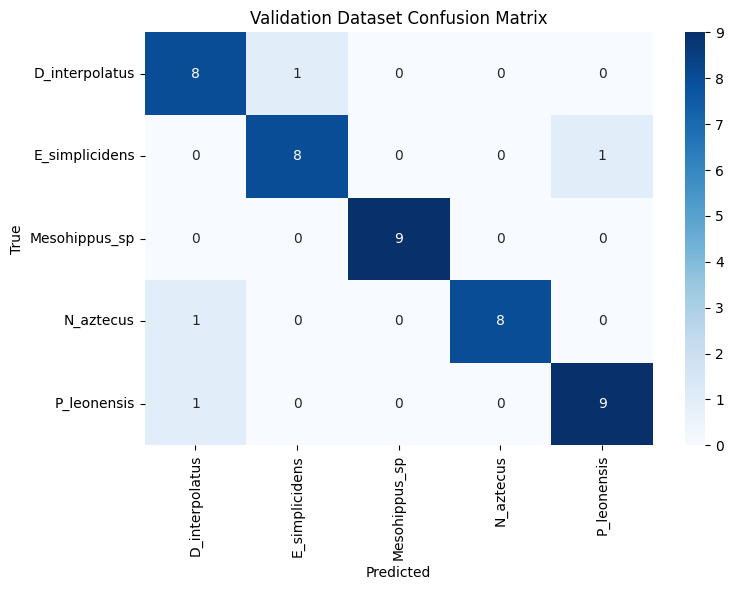

In [9]:
# Confusion Matrix for validation set
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set model to evaluation mode
model.eval()
    
# Collect predictions and true labels
true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Get class names from dataset

# Shorten class labels by removing '_resized_gray'
class_names = [name.replace('_resized_gray', '') for name in dataset.classes]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Validation Dataset Confusion Matrix')
plt.tight_layout()
plt.show()

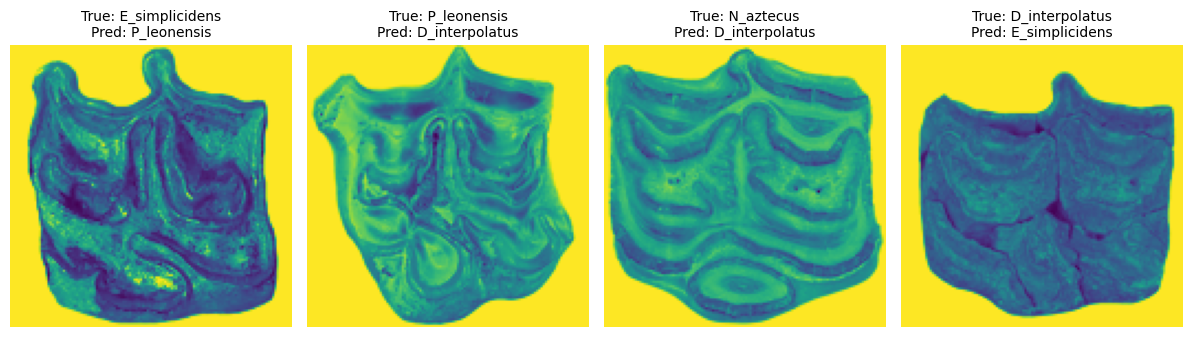

In [10]:
# Show images for mis-classifed teeth from the validation datasets

import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

misclassified_images = []
misclassified_true_labels = []
misclassified_pred_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Find misclassified indices
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_true_labels.append(labels[i].cpu().item())
                misclassified_pred_labels.append(predicted[i].cpu().item())

# Show a few misclassified images
num_to_show = min(10, len(misclassified_images))  # Show up to 10
plt.figure(figsize=(15, 8))
for idx in range(num_to_show):
    img = misclassified_images[idx]
    true_label = class_names[misclassified_true_labels[idx]]
    pred_label = class_names[misclassified_pred_labels[idx]]

    plt.subplot(2, 5, idx + 1)
    plt.imshow(img.permute(1, 2, 0))  # Convert from CxHxW to HxWxC
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Let's Test the Model
Now let's load a test dataset that has not been seen by the model up to now. 

In [11]:
# Now we will TEST the model with unseen test data

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)  # Compute loss for this batch
        test_loss += loss.item()           # Accumulate loss

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Average loss across all batches
test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.1805, Test Accuracy: 95.65%


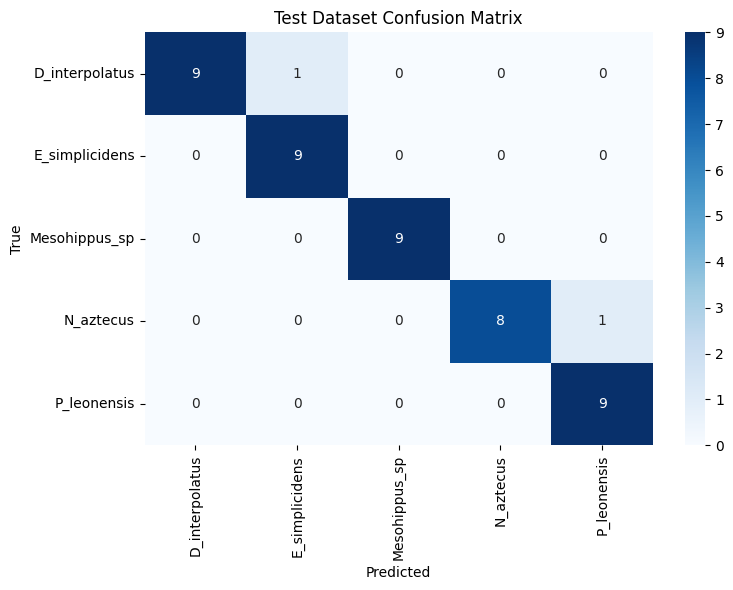

In [12]:
# Confusion Matrix for the TEST dataset results

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()
true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in test_loader:  # Test Dataset
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Get class names from dataset
class_names = [name.replace('_resized_gray', '') for name in dataset.classes]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Test Dataset Confusion Matrix')
plt.tight_layout()
plt.show()

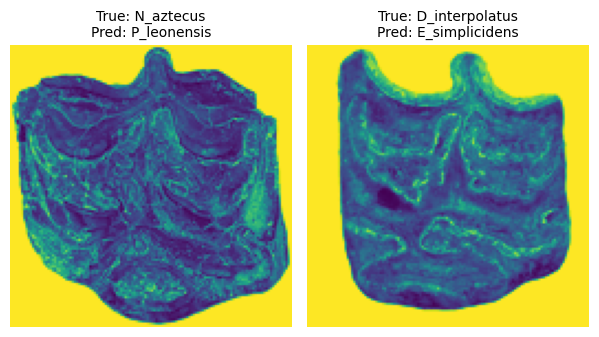

In [13]:
# Show images for mis-classifed teeth from the test datasets

import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

misclassified_images = []
misclassified_true_labels = []
misclassified_pred_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Find misclassified indices
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_true_labels.append(labels[i].cpu().item())
                misclassified_pred_labels.append(predicted[i].cpu().item())

# Show a few misclassified images
num_to_show = min(10, len(misclassified_images))  # Show up to 10
plt.figure(figsize=(15, 8))
for idx in range(num_to_show):
    img = misclassified_images[idx]
    true_label = class_names[misclassified_true_labels[idx]]
    pred_label = class_names[misclassified_pred_labels[idx]]

    plt.subplot(2, 5, idx + 1)
    plt.imshow(img.permute(1, 2, 0))  # Convert from CxHxW to HxWxC
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
# This function shows the architecture for our SimpleCNN model

print(model)

SimpleCNN(
  (conv_layer): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=5, bias=True)
  )
)


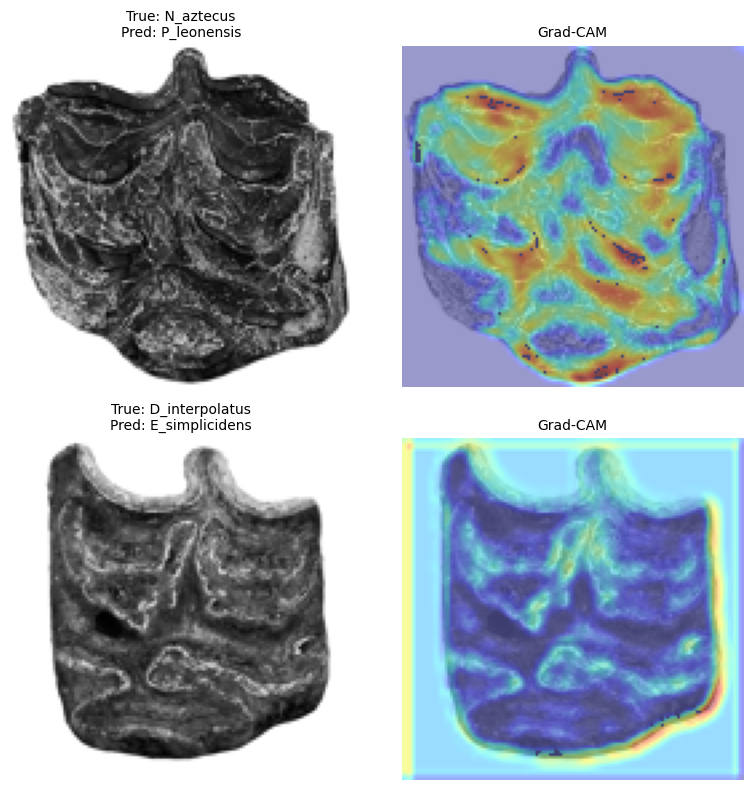

In [22]:
# Let's see what features the computer uses to classify our images using a heatmap (GRAD-CAM)

num_to_show = min(10, len(misclassified_images))  # Show up to 10 teeth
rows = num_to_show
cols = 2  # Original + Grad-CAM

fig, axes = plt.subplots(rows, cols, figsize=(8, 4 * rows))

for idx in range(num_to_show):
    img = misclassified_images[idx]
    true_label = misclassified_true_labels[idx]
    pred_label = misclassified_pred_labels[idx]

    # Generate Grad-CAM
    heatmap = generate_gradcam(img, pred_label)

    # Convert image tensor to numpy
    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # Resize heatmap to match image size
    heatmap_tensor = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0)
    heatmap_resized = torch.nn.functional.interpolate(
        heatmap_tensor,
        size=img_np.shape[:2],
        mode='bilinear',
        align_corners=False
    ).squeeze().numpy()

    # Mask background
    mask = img_np.mean(axis=2) > 0.05
    heatmap_masked = heatmap_resized * mask

    # Plot original image
    axes[idx, 0].imshow(img_np, cmap='gray')
    axes[idx, 0].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", fontsize=10)
    axes[idx, 0].axis('off')

    # Plot Grad-CAM overlay
    axes[idx, 1].imshow(img_np, cmap='gray', alpha=0.6)
    axes[idx, 1].imshow(heatmap_masked, cmap='jet', alpha=0.4)
    axes[idx, 1].set_title("Grad-CAM", fontsize=10)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

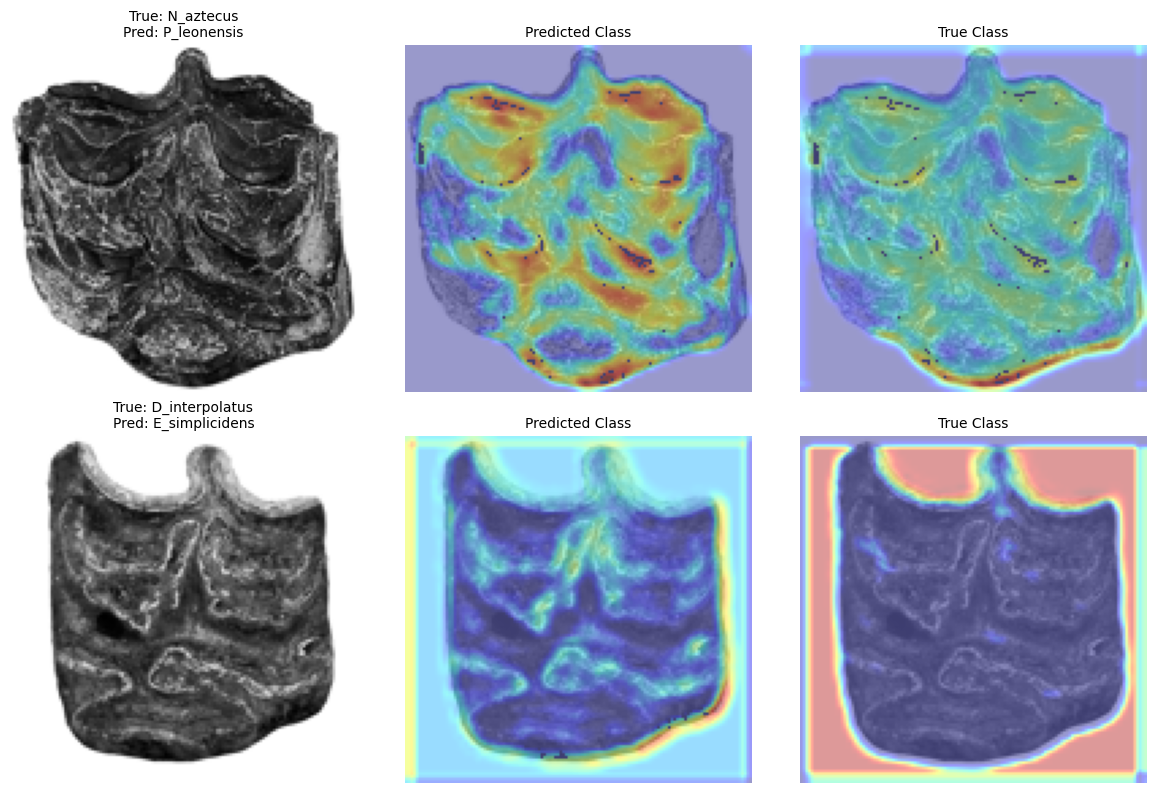

In [24]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set model to evaluation mode
model.eval()

# Use the last Conv2d layer in conv_layer
target_layer = model.conv_layer[3]  # Last convolutional layer

# Hooks to capture activations and gradients
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

def generate_gradcam(image_tensor, class_idx):
    activations.clear()
    gradients.clear()

    # Forward pass
    output = model(image_tensor.unsqueeze(0).to(device))
    model.zero_grad()
    output[0, class_idx].backward()

    # Compute Grad-CAM
    activation = activations[0].squeeze().detach()
    gradient = gradients[0].squeeze().detach()
    weights = gradient.mean(dim=(1, 2))
    cam = torch.zeros(activation.shape[1:])
    for i, w in enumerate(weights):
        cam += w * activation[i]
    cam = cam.cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cam - np.min(cam)
    cam = cam / np.max(cam)
    return cam

def crop_tooth(img_np, threshold=0.05):
    """Crop the tooth region based on intensity threshold."""
    mask = img_np.mean(axis=2) > threshold
    coords = np.argwhere(mask)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return img_np[y_min:y_max+1, x_min:x_max+1, :], (y_min, y_max, x_min, x_max)

# Visualize misclassified images
num_to_show = min(5, len(misclassified_images))
fig, axes = plt.subplots(num_to_show, 3, figsize=(12, 4 * num_to_show))

for idx in range(num_to_show):
    img = misclassified_images[idx]
    true_label = misclassified_true_labels[idx]
    pred_label = misclassified_pred_labels[idx]

    # Convert image tensor to numpy
    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # Crop tooth region
    cropped_img, (y_min, y_max, x_min, x_max) = crop_tooth(img_np)

    # Generate Grad-CAM for predicted and true classes
    heatmap_pred = generate_gradcam(img, pred_label)
    heatmap_true = generate_gradcam(img, true_label)

    # Resize heatmaps to match cropped image size
    def resize_heatmap(heatmap, target_size):
        heatmap_tensor = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0)
        return torch.nn.functional.interpolate(
            heatmap_tensor,
            size=target_size,
            mode='bilinear',
            align_corners=False
        ).squeeze().numpy()

    heatmap_pred_resized = resize_heatmap(heatmap_pred, cropped_img.shape[:2])
    heatmap_true_resized = resize_heatmap(heatmap_true, cropped_img.shape[:2])

    # Mask background inside cropped region
    mask = cropped_img.mean(axis=2) > 0.05
    heatmap_pred_masked = heatmap_pred_resized * mask
    heatmap_true_masked = heatmap_true_resized * mask

    # Column 1: Original cropped image
    axes[idx, 0].imshow(cropped_img, cmap='gray')
    axes[idx, 0].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", fontsize=10)
    axes[idx, 0].axis('off')

    # Column 2: Grad-CAM for predicted class
    axes[idx, 1].imshow(cropped_img, cmap='gray', alpha=0.6)
    axes[idx, 1].imshow(heatmap_pred_masked, cmap='jet', alpha=0.4)
    axes[idx, 1].set_title("Predicted Class", fontsize=10)
    axes[idx, 1].axis('off')

    # Column 3: Grad-CAM for true class
    axes[idx, 2].imshow(cropped_img, cmap='gray', alpha=0.6)
    axes[idx, 2].imshow(heatmap_true_masked, cmap='jet', alpha=0.4)
    axes[idx, 2].set_title("True Class", fontsize=10)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()